# K-means

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, silhouette_score
import pickle
import os

### leemos el Dataset

In [54]:
df= pd.read_csv("../data/raw/housing.csv")
df.head
# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nNombre de columnas:")
print(df.columns.tolist())
print("\nPrimeras Filas:")
df.head()

Dataset shape: (20640, 9)

Nombre de columnas:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Primeras Filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Información del conjunto de datos y control de calidad
>
> Examinemos la estructura del conjunto de datos, los tipos de datos y verifiquemos si faltan valores:

In [55]:
# Obtener información detallada del conjunto de datos
df.info()
df.describe()

# Comprobar valores faltantes
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Extraer columnas relevantes
Para nuestro análisis de agrupamiento de K-means, nos centraremos en tres columnas importantes:

- Latitud: Coordenada de latitud geográfica
- Longitud: Coordenada de longitud geográfica
- MedInc: Ingresos medios en el grupo de bloques (en decenas de miles de dólares)
>
> Examinamos estas columnas y analizamos sus distribuciones:

In [56]:
# Extraer las columnas relevantes para la agrupación
columns_of_interest = ['Latitude', 'Longitude', 'MedInc']
df_cluster = df[columns_of_interest].copy()

df_cluster.head()

df_cluster.shape

df_cluster.describe()

,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


### EDA: Comprobación de la calidad de los datos
>
> Procederemos con la agrupación en clústeres de K-means, haremos un análisis exploratorio rápido de los datos para asegurarnos de que estén limpios y sean aptos para la agrupación:

### Comprobación de valores y tipos de datos faltantes

In [57]:
# Verificar valores faltantes y tipos de datos
print("\nValores faltantes por columna:")
print(df_cluster.isnull().sum())
print("\nTipos de datos:")
df_cluster.dtypes
#print("\nNúmero de filas duplicadas:")
df_cluster.duplicated().sum()


Valores faltantes por columna:
Latitude     0
Longitude    0
MedInc       0
dtype: int64

Tipos de datos:


np.int64(5)


Resultados de calidad de datos: No tenemos valores faltantes, tipos de datos adecuados y solo 5 filas duplicadas.

### Resumen estadístico y detección de valores atípicos (outliers)

In [58]:
# Resumen estadístico 
print("Statistical Summary:")
print(df_cluster.describe())

# Comprobar posibles valores atípicos
print("\nPotential outliers:")
Q1 = df_cluster.quantile(0.25)
Q3 = df_cluster.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_cluster < (Q1 - 1.5 * IQR)) | (df_cluster > (Q3 + 1.5 * IQR))).sum()
print(outliers)

Statistical Summary:
           Latitude     Longitude        MedInc
count  20640.000000  20640.000000  20640.000000
mean      35.631861   -119.569704      3.870671
std        2.135952      2.003532      1.899822
min       32.540000   -124.350000      0.499900
25%       33.930000   -121.800000      2.563400
50%       34.260000   -118.490000      3.534800
75%       37.710000   -118.010000      4.743250
max       41.950000   -114.310000     15.000100

Potential outliers:
Latitude       0
Longitude      0
MedInc       681
dtype: int64


### Visualización de Distribución de datos

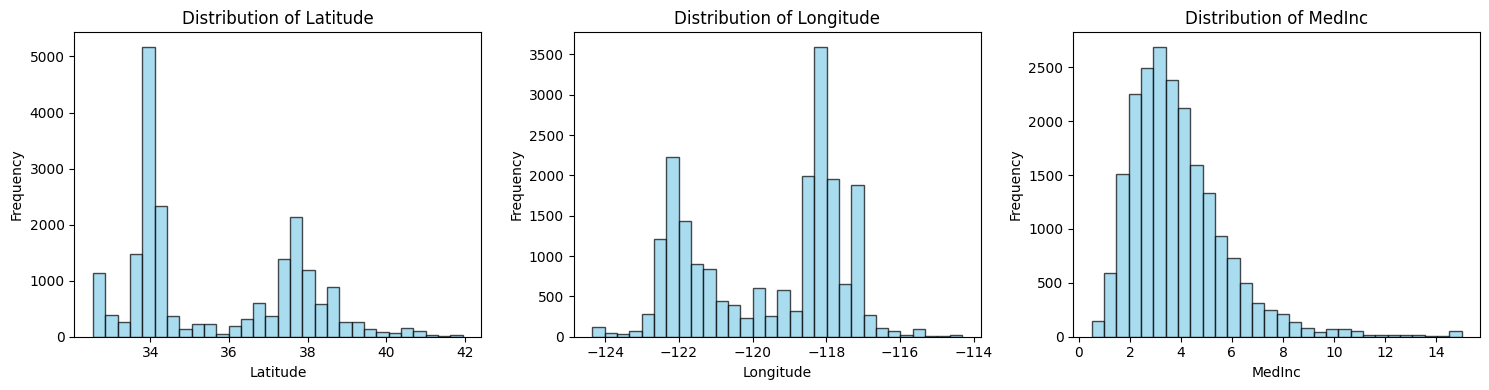

In [59]:
# Histograma para cada variable
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(df_cluster.columns):
    axes[i].hist(df_cluster[col], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

> Los histogramas muestran patrones de concentración geográfica y una distribución de ingresos asimétrica hacia la derecha, lo cual es característico de los datos reales

### Analisis de Correlación

Correlation Matrix:


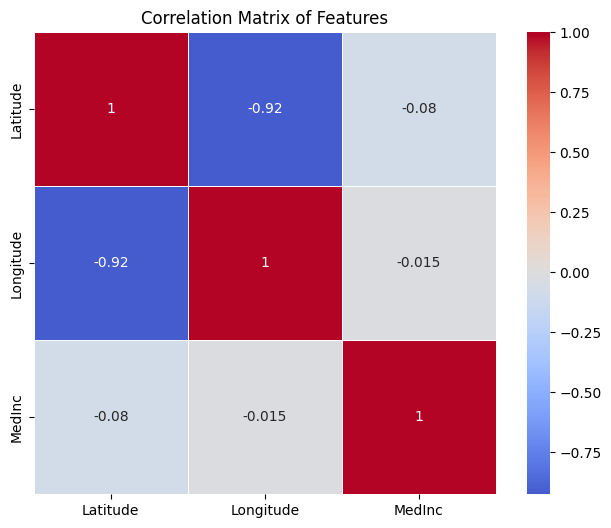

In [60]:
# Calcular la matriz de correlación
correlation_matrix = df_cluster.corr()
print("Correlation Matrix:")
correlation_matrix

# Crear un mapa de calor para visualizar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

Para la geografía de California, se anticipa una marcada correlación negativa entre latitud y longitud (-0,92). En cambio, MedInc presenta correlaciones bajas, lo que lo hace adecuado para tareas de agrupamiento.

### Preparación de datos para K-means
Antes de aplicar la agrupación en clústeres de K-means, debemos preparar nuestros datos correctamente:
>
- Gestionar los valores faltantes (si los hay).
- Escalar las características para garantizar que todas las variables contribuyan por igual a los cálculos de distancia.
- Dividir los datos en conjuntos de entrenamiento y de prueba para su validación.

In [61]:
# Verifique los valores faltantes en nuestro conjunto de datos de agrupamiento
print("Missing values in clustering dataset:")
df_cluster.isnull().sum()

# Eliminar cualquier fila con valores faltantes (si hay alguno)
df_cluster_clean = df_cluster.dropna()
df_cluster_clean.shape

# Para K-means, no tenemos variables objetivo, por lo que dividimos las características
X_train, X_test = train_test_split(
    df_cluster_clean, 
    test_size=0.2, 
    random_state=42,
    stratify=None  #No se necesita estratificación/dividir para el aprendizaje no supervisado.
)
X_train.shape
X_test.shape

# Display the first few rows of each split
print("\nFirst 5 rows of training set:")
X_train.head()
print("\nFirst 5 rows of testing set:")
X_test.head()

Missing values in clustering dataset:

First 5 rows of training set:

First 5 rows of testing set:


,Latitude,Longitude,MedInc
20046,36.06,-119.01,1.6812
3024,35.14,-119.46,2.5313
15663,37.80,-122.44,3.4801
20484,34.28,-118.72,5.7376
9814,36.62,-121.93,3.7250


Los datos han sido particionados de forma adecuada en conjuntos de entrenamiento y prueba. Esto facilita entrenar el modelo K-means usando los datos de entrenamiento y luego medir su desempeño con datos nuevos que no ha visto antes.

### Construir un modelo K-Means
implementamos el algoritmo de agrupamiento K-Means para agrupar las viviendas en seis grupos según su ubicación geográfica y su ingreso medio.

### Escalado de características
Antes de aplicar K-means, debemos escalar nuestras características, ya que tienen diferentes rangos (coordenadas vs. ingresos). Esto garantiza que todas las características contribuyan por igual a los cálculos de distancia:

In [62]:
# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar y transformar los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transforme los datos de prueba utilizando el mismo escalador
X_test_scaled = scaler.transform(X_test)
X_train.shape
X_train_scaled.shape
print("\nPrimeras 5 filas de datos de entrenamiento escalados:")
X_train_scaled[:5]


Primeras 5 filas de datos de entrenamiento escalados:


array([[-1.3728112 ,  1.27258656, -0.326196  ],
       [-0.87669601,  0.70916212, -0.03584338],
       [-0.46014647, -0.44760309,  0.14470145],
       [-1.38217186,  1.23269811, -1.01786438],
       [ 0.5320839 , -0.10855122, -0.17148831]])

### Entrenamiento del modelo K-Means
Ahora crearemos y entrenaremos el modelo K-Means con seis clústeres. El modelo identificará patrones en los datos para agrupar casas similares:

In [72]:
# Inicializar K-medias con 6 clústeres
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

# Ajuste el modelo a los datos de entrenamiento escalados
kmeans.fit(X_train_scaled)

# Obtener etiquetas de clúster para datos de entrenamiento
train_clusters = kmeans.labels_

print(f"K-means entrenado con exito!")
print(f"Number of clusters: {kmeans.n_clusters}")
print(f"Cluster labels for training data: {train_clusters[:10]}...")
print(f"Unique cluster labels: {np.unique(train_clusters)}")
print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")

K-means entrenado con exito!
Number of clusters: 6
Cluster labels for training data: [5 5 0 5 0 4 5 4 5 1]...
Unique cluster labels: [0 1 2 3 4 5]
Cluster centers shape: (6, 3)


### Adición de etiquetas de clúster al conjunto de datos
Agregamos las asignaciones de clúster como una nueva columna a nuestro conjunto de datos de entrenamiento y examinemos la distribución de clústeres:

In [74]:
# Cree una copia de los datos de entrenamiento y agregue etiquetas de clúster
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = train_clusters

print("Training data with cluster labels:")
X_train_clustered.head()

# Verificar la distribución del clúster
print("\nCluster distribution:")
cluster_counts = X_train_clustered['cluster'].value_counts().sort_index()
print(cluster_counts)

# Verificar tipos de datos
print("\nData types:")
X_train_clustered.dtypes

Training data with cluster labels:

Cluster distribution:
cluster
0    1321
1    3380
2     453
3    3931
4    2239
5    5188
Name: count, dtype: int64

Data types:


Latitude     float64
Longitude    float64
MedInc       float64
cluster        int32
dtype: object

### Visualización de clústeres de entrenamiento
Creamos un diagrama de dispersión para visualizar cómo se agrupan las casas por ubicación y se codifican por colores según el clúster:

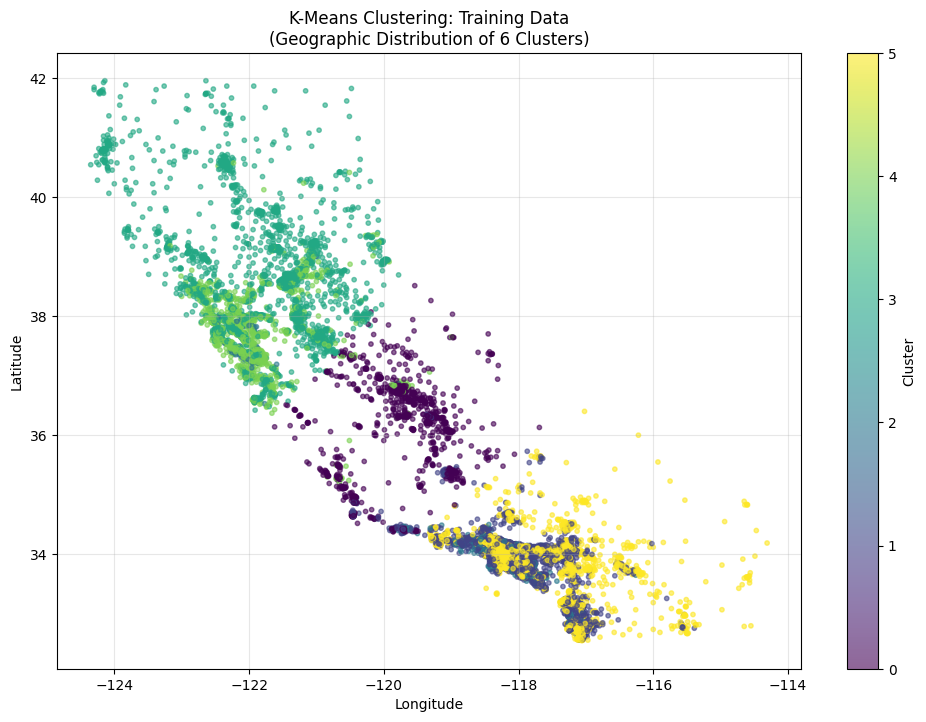

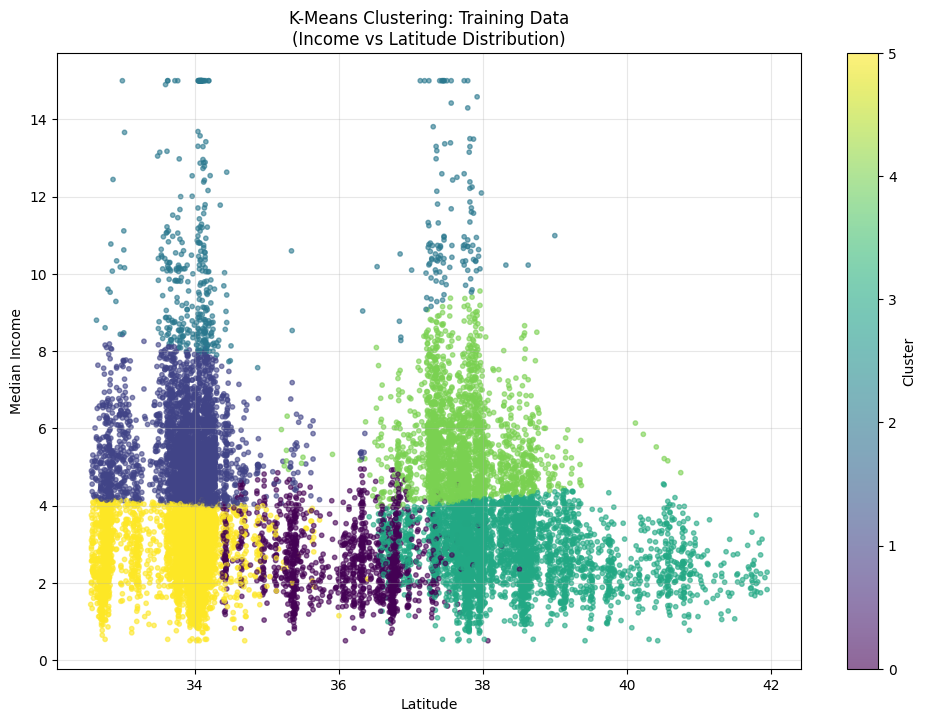

In [ ]:
# Crear un diagrama de dispersión para la agrupación geográfica
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_train_clustered['Longitude'], X_train_clustered['Latitude'], 
                     c=X_train_clustered['cluster'], cmap='viridis', alpha=0.6, s=10)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering: Training Data\n(Geographic Distribution of 6 Clusters)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# Crear un diagrama de dispersión para ingresos vs latitud
plt.figure(figsize=(12, 8))
scatter2 = plt.scatter(X_train_clustered['Latitude'], X_train_clustered['MedInc'], 
                      c=X_train_clustered['cluster'], cmap='viridis', alpha=0.6, s=10)

plt.xlabel('Latitude')
plt.ylabel('Median Income')
plt.title('K-Means Clustering: Training Data\n(Income vs Latitude Distribution)')
plt.colorbar(scatter2, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [75]:
# Predecir clústeres para el conjunto de prueba
test_clusters = kmeans.predict(X_test_scaled)

# Crear una copia de los datos de prueba con etiquetas de clúster
X_test_clustered = X_test.copy()
X_test_clustered['cluster'] = test_clusters

print("Test data with cluster predictions:")
X_test_clustered.head()

# Comparar la distribución del grupo de prueba con el entrenamiento
print("\nTest set cluster distribution:")
test_cluster_counts = X_test_clustered['cluster'].value_counts().sort_index()
print(test_cluster_counts)

print("\nTraining vs Test cluster distribution:")
comparison = pd.DataFrame({
    'Training': cluster_counts,
    'Test': test_cluster_counts
})
comparison

Test data with cluster predictions:

Test set cluster distribution:
cluster
0     337
1     829
2     112
3     962
4     514
5    1374
Name: count, dtype: int64

Training vs Test cluster distribution:


,Training,Test
cluster,,
0,1321,337
1,3380,829
2,453,112
3,3931,962
4,2239,514
5,5188,1374


### Visualización combinada: Datos de entrenamiento y de prueba
Visualicemos juntos los datos de entrenamiento y de prueba para verificar que nuestro modelo se generaliza correctamente:

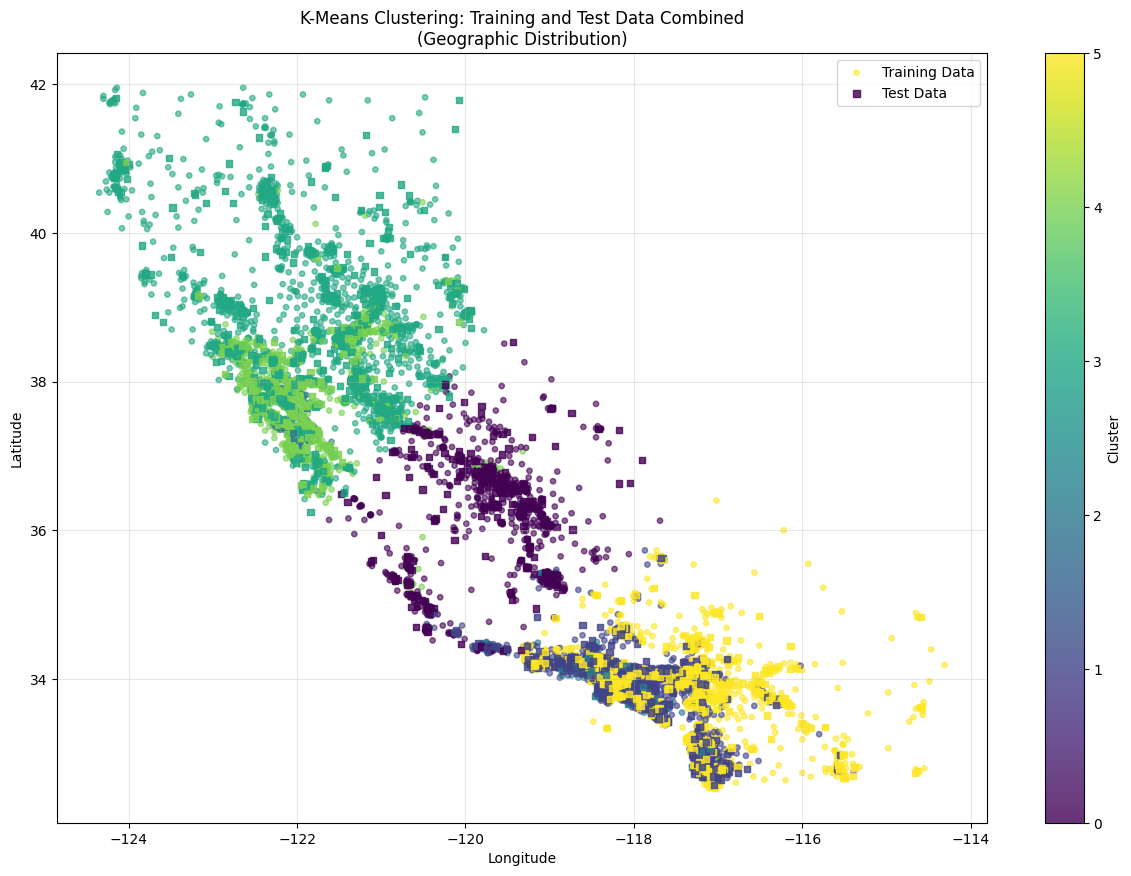

In [ ]:
# Visualización geográfica combinada
plt.figure(figsize=(15, 10))

# Trazar datos de entrenamiento
plt.scatter(X_train_clustered['Longitude'], X_train_clustered['Latitude'], 
           c=X_train_clustered['cluster'], cmap='viridis', alpha=0.6, s=15, 
           label='Training Data', marker='o')

#Trazar datos de prueba con distintos marcadores
plt.scatter(X_test_clustered['Longitude'], X_test_clustered['Latitude'], 
           c=X_test_clustered['cluster'], cmap='viridis', alpha=0.8, s=20, 
           label='Test Data', marker='s')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering: Training and Test Data Combined\n(Geographic Distribution)')
plt.colorbar(label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Entrenar un modelo de clasificación supervisado
Ahora que tenemos las etiquetas de los clústeres de K-means, podemos entrenar un modelo supervisado para predecir estos clústeres. Este es un flujo de trabajo común: usar aprendizaje no supervisado para crear etiquetas y, luego, aprendizaje supervisado para predecirlas.

para el aprendizaje supervisado
Utilizaremos las características originales (latitud, longitud, MedInc) como entrada y las etiquetas de los clústeres como objetivos:

In [82]:
# Preparar características y objetivos para el aprendizaje supervisado
X_train_supervised = X_train[['Latitude', 'Longitude', 'MedInc']].copy()
y_train_supervised = train_clusters

X_test_supervised = X_test[['Latitude', 'Longitude', 'MedInc']].copy()
y_test_supervised = test_clusters

print("Supervised learning data preparation:")
X_train_supervised.shape
y_train_supervised.shape
X_test_supervised.shape
y_test_supervised.shape

print(f"\nTarget classes: {np.unique(y_train_supervised)}")
print(f"Class distribution: {np.bincount(y_train_supervised)}")

Supervised learning data preparation:

Target classes: [0 1 2 3 4 5]
Class distribution: [1321 3380  453 3931 2239 5188]


### Selección y entrenamiento de modelos
Para esta tarea de clasificación, probaremos Random Forest, ya que gestiona bien las características geográficas y numéricas, y lo compararemos con otros modelos:

In [ ]:
# Inicializamos el modelo
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Entrenar y evaluar modelos
results = {}
for name, model in models.items():
    # Entrenar el modelo
    model.fit(X_train_supervised, y_train_supervised)
    
    # Hacer predicciones
    y_pred = model.predict(X_test_supervised)
    
    # Calcular la precision /accuracy
    accuracy = accuracy_score(y_test_supervised, y_pred)
    results[name] = accuracy
    
    print(f"{name} Accuracy: {accuracy:.4f}")

print("\nModel Comparison:")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.4f}")

Random Forest Accuracy: 0.9952
Decision Tree Accuracy: 0.9937
K-Nearest Neighbors Accuracy: 0.9898

Model Comparison:
Random Forest: 0.9952
Decision Tree: 0.9937
K-Nearest Neighbors: 0.9898


### Análisis detallado del mejor modelo
Analicemos en detalle el modelo con mejor rendimiento, incluyendo métricas de clasificación e importancia de las características:

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       337
           1       1.00      1.00      1.00       829
           2       1.00      0.98      0.99       112
           3       0.99      0.99      0.99       962
           4       0.99      1.00      0.99       514
           5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128


Feature Importance:
Latitude: 0.2697
Longitude: 0.2560
MedInc: 0.4743


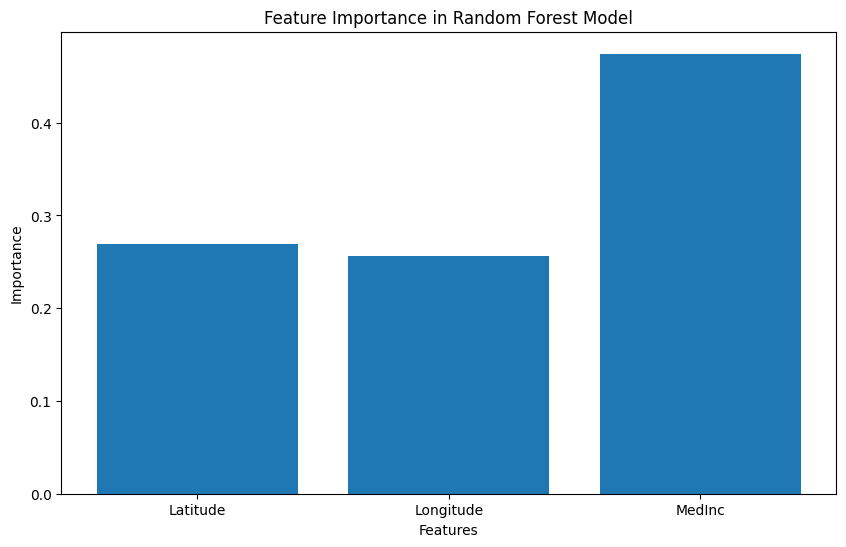

In [ ]:
# Seleccionamos el mejor modelo(Random Forest)
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_supervised, y_train_supervised)
y_pred_best = best_model.predict(X_test_supervised)

# Informe de clasificación detallado
print("Classification Report:")
print(classification_report(y_test_supervised, y_pred_best))

# Importancia de las características
feature_importance = best_model.feature_importances_
features = ['Latitude', 'Longitude', 'MedInc']

print("\nFeature Importance:")
for feature, importance in zip(features, feature_importance):
    print(f"{feature}: {importance:.4f}")

# Visualiza la importancia de las características
plt.figure(figsize=(10, 6))
plt.bar(features, feature_importance)
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

### Resumen
>
- Aprendizaje no supervisado (K-Means): Se agruparon las viviendas de California en 6 grupos según su ubicación e ingresos.
- Aprendizaje supervisado: Se entrenaron modelos de clasificación para predecir la pertenencia a los grupos.
- Rendimiento del modelo: Random Forest logró una precisión del 99,52 % en la predicción de la asignación de grupos.
- Patrones geográficos: Los grupos muestran una clara separación geográfica en California.

In [81]:
# Comprobación rápida de la puntuación de silueta para 6 grupos
silhouette_avg = silhouette_score(X_train_scaled, train_clusters)
print(f"Silhouette Score for 6 clusters: {silhouette_avg:.4f}")
print("Interpretation: 0.3987 indicates 'moderate' clustering quality")
print("Note: Scores closer to 1.0 indicate better-separated clusters")

Silhouette Score for 6 clusters: 0.3987
Interpretation: 0.3987 indicates 'moderate' clustering quality
Note: Scores closer to 1.0 indicate better-separated clusters


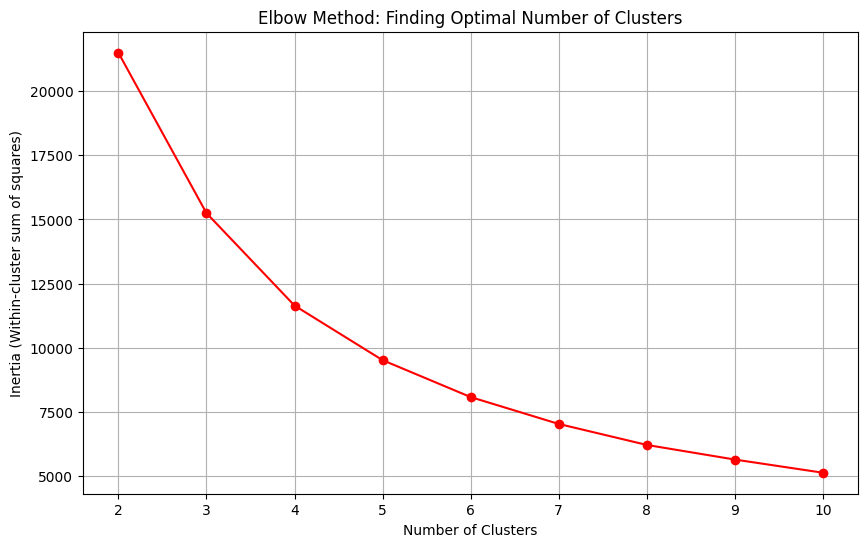

Inertia values:
n_clusters = 2: Inertia = 21504.22
n_clusters = 3: Inertia = 15247.45
n_clusters = 4: Inertia = 11639.22
n_clusters = 5: Inertia = 9509.21
n_clusters = 6: Inertia = 8069.19
n_clusters = 7: Inertia = 7020.68
n_clusters = 8: Inertia = 6201.63
n_clusters = 9: Inertia = 5630.97
n_clusters = 10: Inertia = 5117.29


In [ ]:
# Definir el rango de números de clúster para probar
cluster_range = range(2, 11)

# Método del codo para encontrar el número óptimo de clústeres
inertias = []

for n_clusters in cluster_range:
    kmeans_temp = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_temp.fit(X_train_scaled)
    inertias.append(kmeans_temp.inertia_)

#Trazar la curva del codo
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertias, 'ro-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method: Finding Optimal Number of Clusters')
plt.grid(True)
plt.show()

print("Inertia values:")
for i, inertia in enumerate(inertias):
    print(f"n_clusters = {cluster_range[i]}: Inertia = {inertia:.2f}")

> Conclusión: ¡Lo óptimo son 2 o 3 clústeres.
>
> Visualicemos cómo se ven 2 y 3 clústeres:

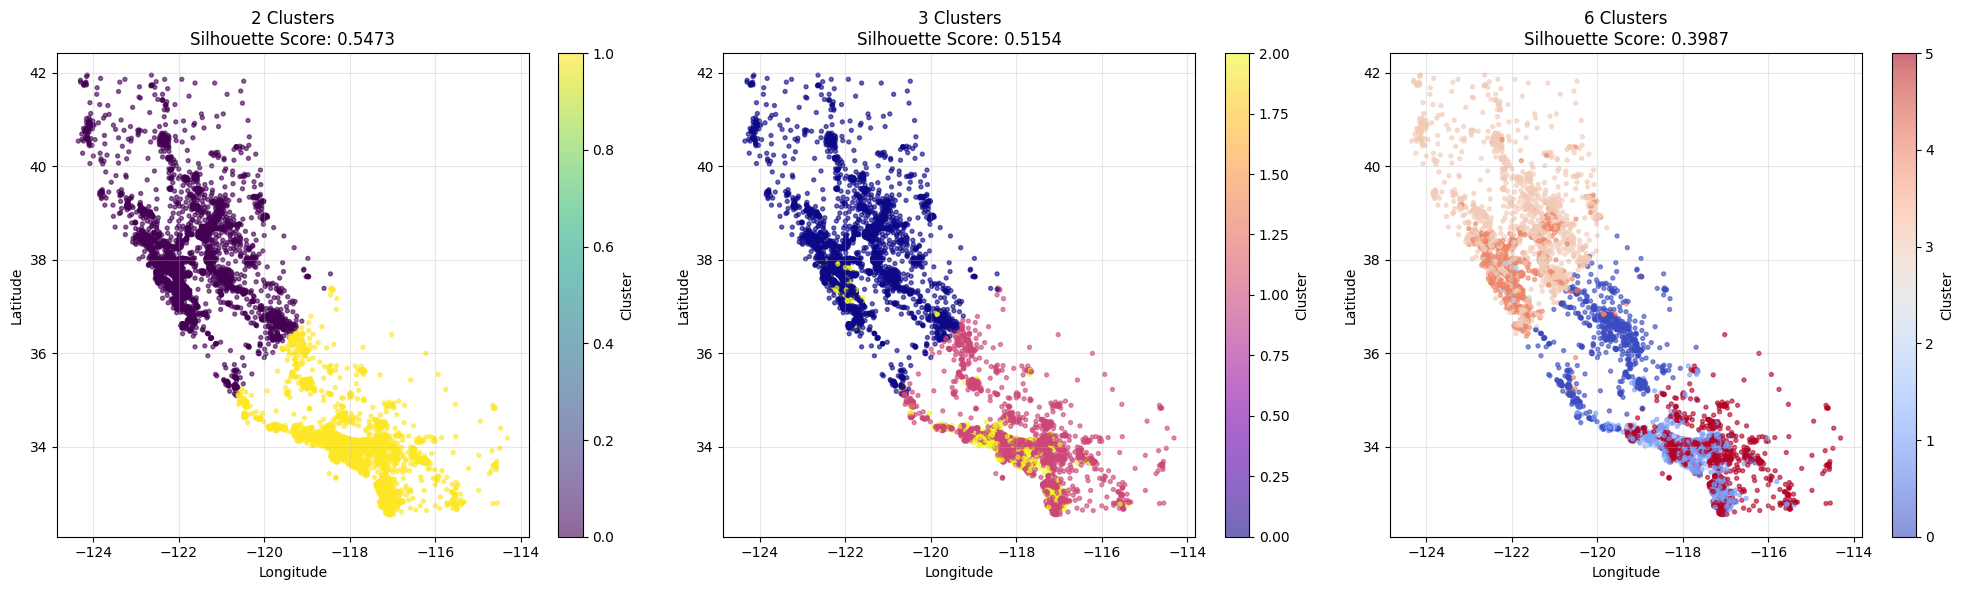

Interpretación geográfica:
2 clusters: Probablemente Norte vs. Sur de California
3 clusters: Probablemente norte, centro y sur de California
6 clusters: Sobresegmentación con límites poco claros

Recomendación: utilice 2 o 3 clústeres para regiones geográficas más significativas


In [ ]:
# Compare visualmente 2, 3 y 6 grupos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cluster_options = [2, 3, 6]
colors = ['viridis', 'plasma', 'coolwarm']

for i, (n_clusters, cmap) in enumerate(zip(cluster_options, colors)):
    # Entrene K-means con diferentes números de clúster
    kmeans_temp = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    temp_labels = kmeans_temp.fit_predict(X_train_scaled)
    
    # Calcular puntuacion de silueta temporal
    temp_silhouette = silhouette_score(X_train_scaled, temp_labels)
    
    # Crear un marco de datos temporal para trazar gráficos
    temp_df = X_train.copy()
    temp_df['cluster'] = temp_labels
    
    # Plot
    scatter = axes[i].scatter(temp_df['Longitude'], temp_df['Latitude'], 
                             c=temp_df['cluster'], cmap=cmap, alpha=0.6, s=8)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'{n_clusters} Clusters\nSilhouette Score: {temp_silhouette:.4f}')
    axes[i].grid(True, alpha=0.3)
    
    # Agregar barra de color
    plt.colorbar(scatter, ax=axes[i], label='Cluster')

plt.tight_layout()
plt.show()

# Interpretacion de los resultados
print("Interpretación geográfica:")
print("2 clusters: Probablemente Norte vs. Sur de California")
print("3 clusters: Probablemente norte, centro y sur de California") 
print("6 clusters: Sobresegmentación con límites poco claros")
print("\nRecomendación: utilice 2 o 3 clústeres para regiones geográficas más significativas")

### Persistencia del modelo
Conservemos el modelo K-means y el mejor modelo supervisado.

In [ ]:
# Crea el directorio K_means si no existe
os.makedirs('../models/K_means', exist_ok=True)

# Guardar el modelo K-means
with open('../models/K_means/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Guardar el escalador (necesario para predicciones)
with open('../models/K_means/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Salvar el mejor modelo supervisado (Random Forest)
with open('../models/K_means/best_supervised_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Models saved successfully!")
print("- K-means model: ../models/K_means/kmeans_model.pkl")
print("- Scaler: ../models/K_means/scaler.pkl") 
print("- Supervised model: ../models/K_means/best_supervised_model.pkl")

Models saved successfully!
- K-means model: ../models/K_means/kmeans_model.pkl
- Scaler: ../models/K_means/scaler.pkl
- Supervised model: ../models/K_means/best_supervised_model.pkl
